# Lambda function

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, fmin

In [2]:
x = np.arange(10)
times_2 = lambda x: x * 2
y = times_2(x)
 
# or using it directly
if any((lambda x: x % 2 == 0)(x)):
    print("even")

# using list comp
if any([x % 2 == 0 for x in x]):
    print("same")

# using gen_expr
if any(x % 2 == 0 for x in x):
    print("way - faster")


even
same
way - faster


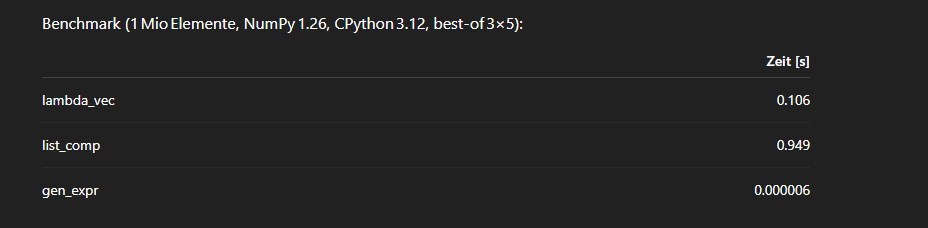

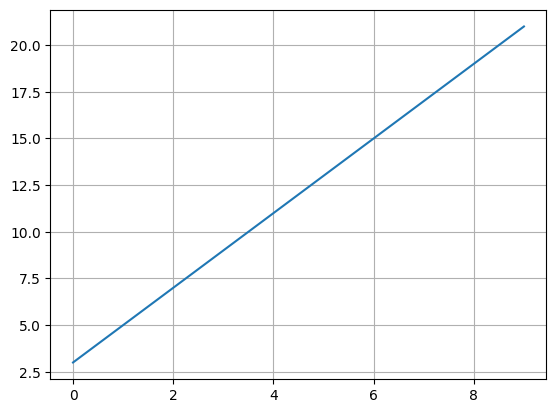

In [4]:
def my_lin_func(a=1, b=0):
    """
    Linear function
    :param a: slope
    :param b: intercept
    :return: FUNCTION that takes x and returns y!
    """
    my_lin = lambda x: a * x + b # lambda closure
    def my_lin2(x):
        return a * x + b # closure
    return my_lin
    # return my_lin2

# call
my_lin_func(2, 3)
plt.plot(x, my_lin_func(2, 3)(x), label="y=2x+3")
plt.grid()

# Curve Fitting

Optimization terminated successfully.
         Current function value: -0.006747
         Iterations: 9
         Function evaluations: 18


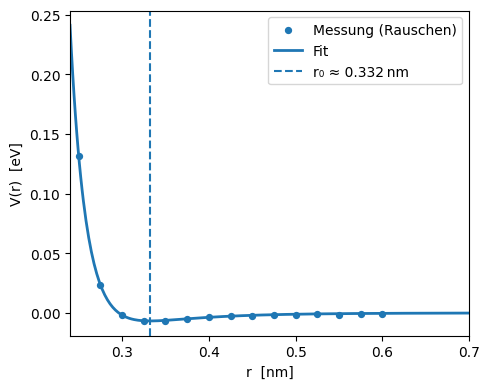

Analytisches Minimum       : r₀ = 0.3322 nm
Naive Schätzung aus Daten  : r₀ ≈ 0.3250 nm
Fit‑basierte Schätzung     : r₀ ≈ 0.3324 nm
Fit‑basierte Schätzung (fmin): r₀ ≈ 0.3324 nm


In [ ]:
# LJ‑Parameter (Literaturwerte, leicht gerundet)
epsilon = 6.8e-3      # eV
sigma   = 0.296       # nm

def lj_potential(r, eps=epsilon, sig=sigma):
    """Lennard‑Jones‑Potential 4 ε [(σ/r)^12 − (σ/r)^6]."""
    inv = sig / r
    inv6 = inv**6
    return 4 * eps * (inv6**2 - inv6)

# --- Messdaten generieren ----------------------------------------------------
rng = np.random.default_rng(0)
r_exp = np.linspace(0.25, 0.6, 15)
noise = rng.normal(0, 5e-4, size=r_exp.size)          # ±0.5 meV Rauschen
V_exp = lj_potential(r_exp) + noise

# --- Gleichgewichtsabstand analytisch ----------------------------------------
r0_true = 2**(1/6) * sigma         # Minimum des LJ‑Potentials

# --- R0 aus „Messung“ grob schätzen -----------------------------------------
r0_naiv = r_exp[np.argmin(V_exp)]  # Minimum der verrauschten Punkte

# --- Curve‑Fit, um eps & sig zu schätzen, dann r0 ---------------------------
p_opt, _ = curve_fit(lj_potential, r_exp, V_exp, p0=[epsilon, sigma])
eps_fit, sig_fit = p_opt
r0_fit = 2**(1/6) * sig_fit
f_min_val = fmin(lj_potential, r0_fit, args=(eps_fit, sig_fit))[0]


# --- Plot --------------------------------------------------------------------
plt.figure(figsize=(5, 4))
plt.scatter(r_exp, V_exp, s=18, label="Messung (Rauschen)")
r_plot = np.linspace(0.24, 0.7, 300)
plt.plot(r_plot, lj_potential(r_plot, eps_fit, sig_fit), label="Fit", lw=2)
plt.axvline(r0_fit, ls="--", label=f"r₀ ≈ {r0_fit:.3f} nm")
plt.xlabel("r  [nm]")
plt.ylabel("V(r)  [eV]")
plt.legend()
plt.xlim(0.24, 0.7)

plt.tight_layout()
plt.show()

# --- Ergebnisse --------------------------------------------------------------
print(f"Analytisches Minimum       : r₀ = {r0_true:.4f} nm")
print(f"Naive Schätzung aus Daten  : r₀ ≈ {r0_naiv:.4f} nm")
print(f"Fit‑basierte Schätzung     : r₀ ≈ {r0_fit:.4f} nm")
print(f"Fit‑basierte Schätzung (fmin): r₀ ≈ {f_min_val:.4f} nm") # downhill-simplex

# Interpolation & I/O Examples
Begleit‑Jupyter‑Notebook zu den Folien *(ab Interpolation)*.

## 1 · Interpolation mit `scipy.interpolate`

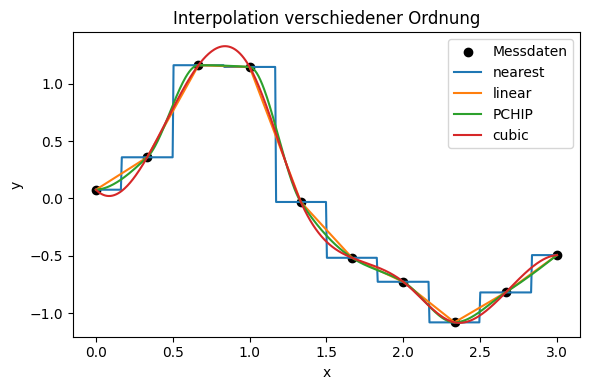

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, PchipInterpolator

# Messdaten (rauschiges sin‑Signal)
rng = np.random.default_rng(42)
x_data = np.arange(0, 3.1, 1/3)
y_data = np.sin(2 * x_data) + rng.normal(0, 0.25, size=x_data.size)

# Punkte für glatte Kurven
x_fine = np.linspace(x_data[0], x_data[-1], 500)

# Interpolations­methoden
methods = {
    'nearest': interp1d(x_data, y_data, kind='nearest'),
    'linear' : interp1d(x_data, y_data, kind='linear'),
    'PCHIP'  : PchipInterpolator(x_data, y_data),
    'cubic'  : interp1d(x_data, y_data, kind='cubic'),
}

plt.figure(figsize=(6, 4))
plt.scatter(x_data, y_data, color='k', label='Messdaten')
for name, f in methods.items():
    plt.plot(x_fine, f(x_fine), label=name)
plt.legend(); plt.xlabel('x'); plt.ylabel('y'); plt.title('Interpolation verschiedener Ordnung')
plt.tight_layout(); plt.show()

*Nearest* ist stückweise konstant, *linear* verbindet Punkte geradlinig, *PCHIP* respektiert Monotonie, und *cubic* liefert eine glatte kubische Spline‑Kurve.

## 2 · `sys.argv`, `input()` & Eingabe‑Validierung

Folgendes Beispiel‑Skript demonstriert den Umgang mit Kommandozeilen‑Argumenten und Benutzereingaben – inkl. Absicherung gegen bösartige Eingaben.
```python
import sys, time
ANSI_RED  = "\033[91m"; ANSI_GRN = "\033[92m"; ANSI_RST = "\033[0m"

def safe_int(s, /, *, max_value=10**6):
    """Konvertiert s zu int, wirft ValueError / OverflowError bei Problemen."""
    n = int(s)
    if n < 0 or n > max_value:
        raise ValueError(f"{n} außerhalb des gültigen Bereichs (0–{max_value}).")
    return n

if __name__ == "__main__":
    try:
        size = safe_int(sys.argv[1])
    except Exception as err:
        print(f"{ANSI_RED}[Fehler] {err}{ANSI_RST}")
        sys.exit(1)

    arr = [0] * size  # könnte böswillig riesig sein
    print(f"{ANSI_GRN}Array der Größe {size} erfolgreich angelegt.{ANSI_RST}")

    name = input("Wie heißt du? → ")
    print("Hallo,", name)
```

In [ ]:
# Live‑Demonstration innerhalb des Notebooks
import sys, importlib, builtins
ANSI_RED='\033[91m'; ANSI_GRN='\033[92m'; ANSI_RST='\033[0m'

def safe_int(s, /, *, max_value=10**6):
    n = int(s)  # kann ValueError werfen
    if n < 0 or n > max_value:
        raise ValueError(f"{n} außerhalb des gültigen Bereichs (0–{max_value}).")
    return n

# Simulierte argv‑Liste (Notebook‑Umgebung)
sys.argv = ['script.py', '1000']

try:
    size = safe_int(sys.argv[1])
    arr = [0] * size
    print(f"{ANSI_GRN}OK –  Array der Größe {size} erstellt{ANSI_RST}")
except Exception as e:
    print(f"{ANSI_RED}Fehler: {e}{ANSI_RST}")


OK –  Array der Größe 1000 erstellt


In [ ]:
# Malicious input simulieren (zu große Zahl)
sys.argv[1] = str(10**9)  # ~1 Milliarde
try:
    size = safe_int(sys.argv[1])
    arr = [0] * size
    print(f"{ANSI_GRN}OK –  Array der Größe {size} erstellt{ANSI_RST}")
except Exception as e:
    print(f"{ANSI_RED}Abgefangen: {e}{ANSI_RST}")


In [ ]:
# input() – Sicheres Parsen
user_age = input('Gib dein Alter ein ➜ ')
try:
    age = safe_int(user_age, max_value=150)
    print(f'Du bist {age} Jahre alt.')
except Exception as e:
    print(f'{ANSI_RED}Ungültige Eingabe: {e}{ANSI_RST}')


Ungültige Eingabe: invalid literal for int() with base 10: 'hello'
